FIRST 5 ROWS
   Drug Dosage (mg)  Systolic Blood Pressure (mmHg)  Heart Rate (BPM)  \
0         -0.128538                        0.303280         -1.881849   
1         -1.846188                        2.865142         -0.929511   
2         -1.252393                       -1.541613          0.363632   
3          1.992515                       -1.142779         -0.766657   
4          0.377100                        0.538410         -0.029263   

   Liver Toxicity Index (U/L)  Blood Glucose Level (mg/dL)  Drug Response  
0                    0.258286                    -0.792011              1  
1                    2.866786                    -0.719447              1  
2                   -0.325370                     0.191314              0  
3                    0.975286                    -0.823355              1  
4                    1.896015                    -0.960130              1  

SHAPE
(500, 6)

COLUMNS
Index(['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)',
      

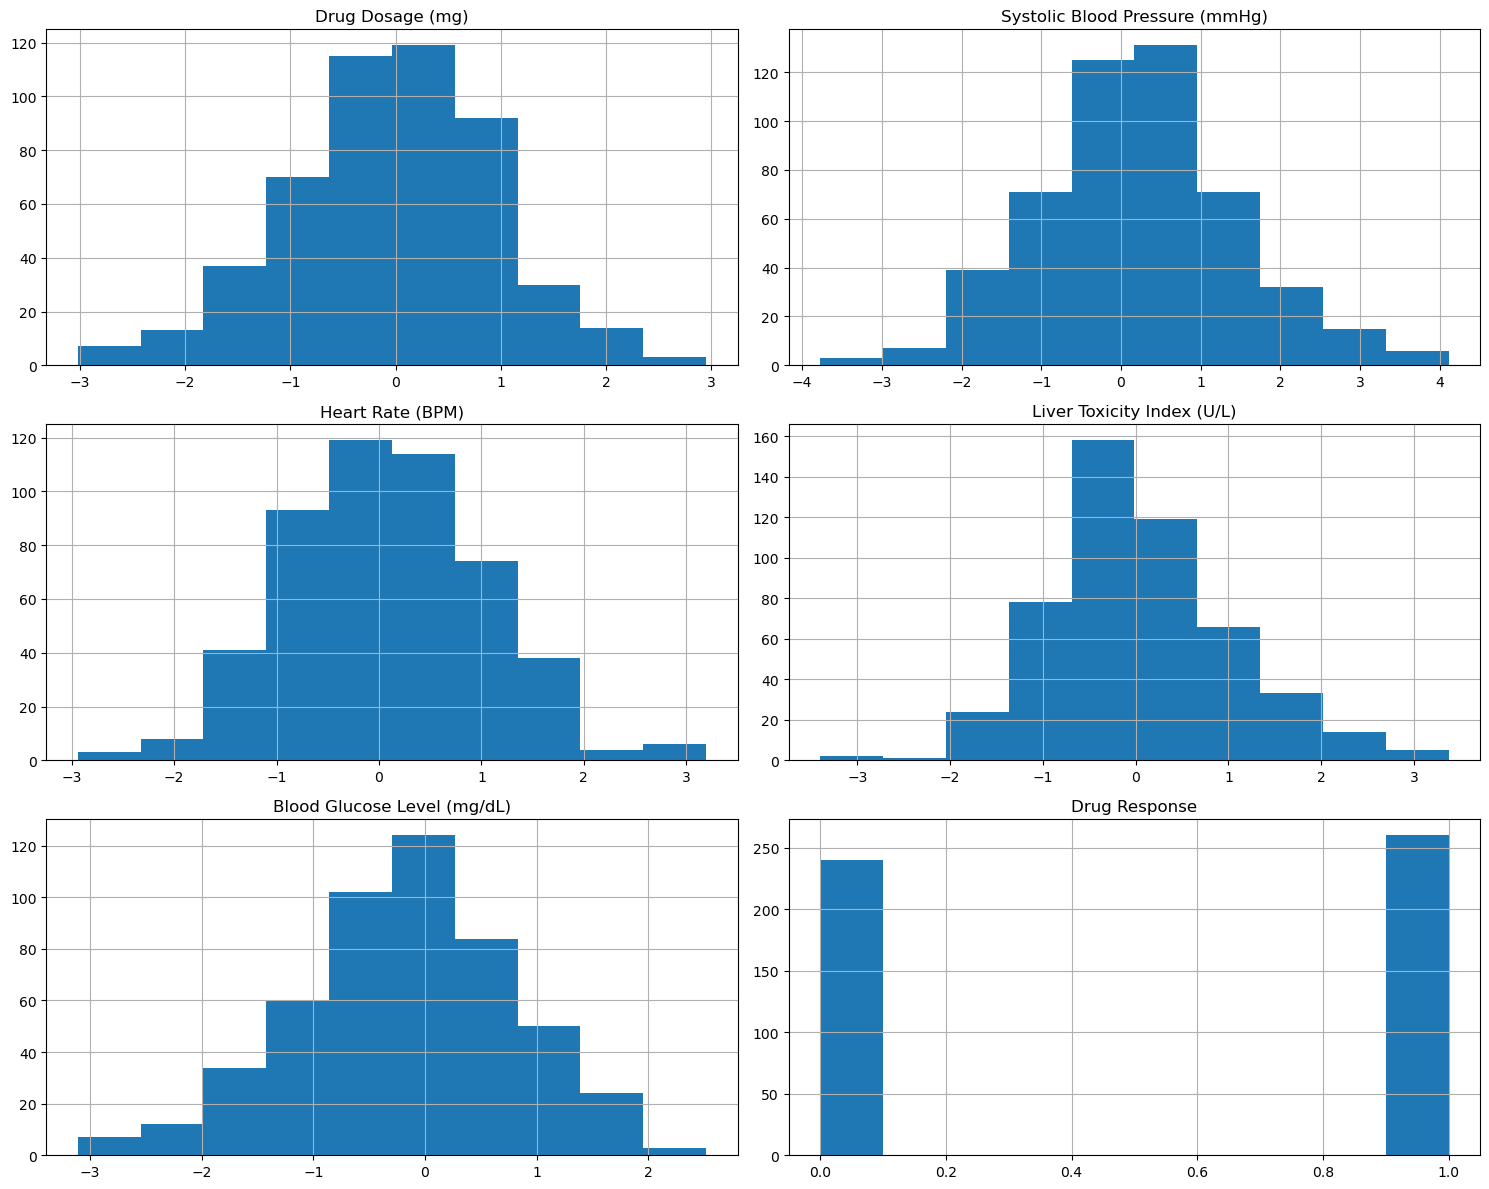

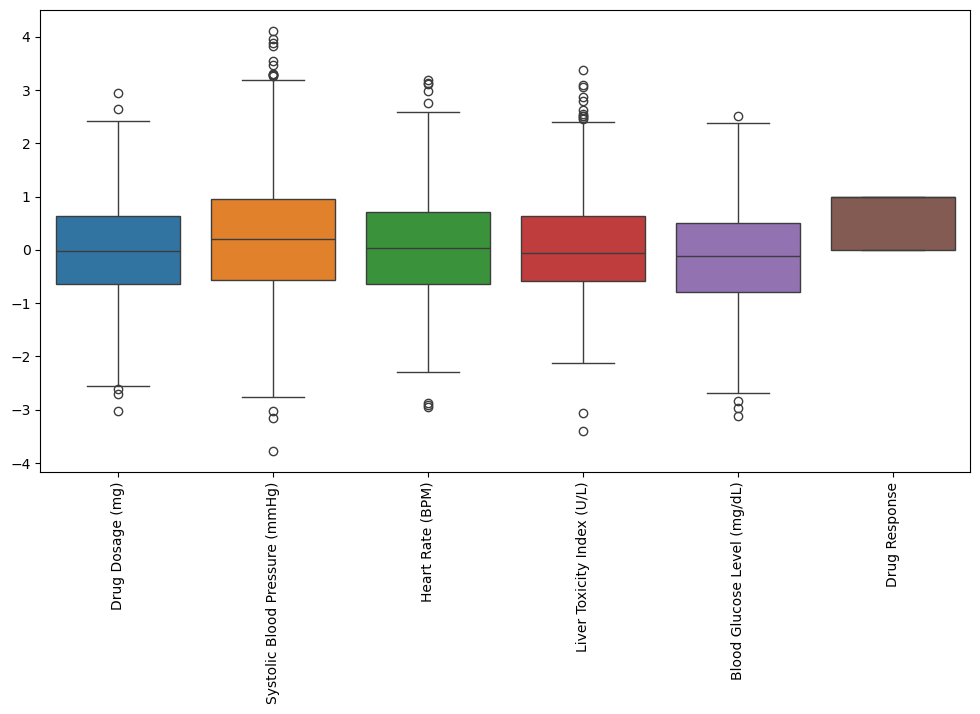

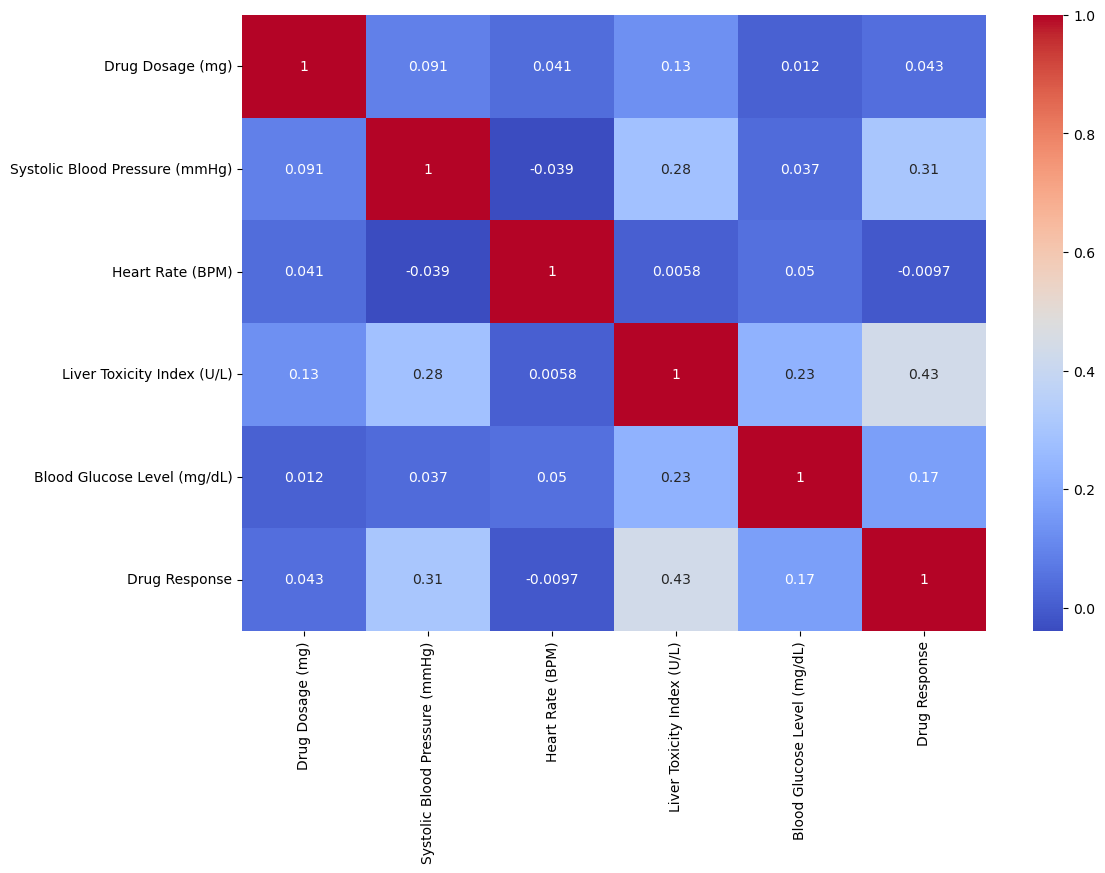

ValueError: Could not interpret value `Drug_Response` for `x`. An entry with this name does not appear in `data`.

In [1]:
# =====================================================
# SUPPORT VECTOR MACHINE PROJECT
# DRUG RESPONSE CLASSIFICATION
# =====================================================

# STEP 1 - IMPORT LIBRARIES

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# STEP 2 - LOAD DATASET

df = pd.read_csv("C:\\Users\\gagan\\Downloads\\Pharma_Industry (1).csv")

print("FIRST 5 ROWS")
print(df.head())

# STEP 3 - DATA EXPLORATION

print("\nSHAPE")
print(df.shape)

print("\nCOLUMNS")
print(df.columns)

print("\nDATA TYPES")
print(df.dtypes)

print("\nINFO")
print(df.info())

print("\nSUMMARY")
print(df.describe())

# STEP 4 - CHECK MISSING VALUES

print("\nMISSING VALUES")
print(df.isnull().sum())

# STEP 5 - HANDLE MISSING VALUES

df = df.replace("?", np.nan)

for col in df.select_dtypes(include='object').columns:
    
    df[col] = df[col].fillna(
        df[col].mode()[0]
    )

for col in df.select_dtypes(include=['int64', 'float64']).columns:
    
    df[col] = df[col].fillna(
        df[col].median()
    )

# STEP 6 - HISTOGRAMS

df.hist(figsize=(15,12))

plt.tight_layout()

plt.show()

# STEP 7 - BOXPLOT

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df.select_dtypes(include=np.number)
)

plt.xticks(rotation=90)

plt.show()

# STEP 8 - HEATMAP

df_heatmap = df.copy()

le = LabelEncoder()

for col in df_heatmap.select_dtypes(include='object').columns:
    
    df_heatmap[col] = le.fit_transform(
        df_heatmap[col]
    )

plt.figure(figsize=(12,8))

sns.heatmap(
    df_heatmap.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

# STEP 9 - CLASS DISTRIBUTION

sns.countplot(
    x='Drug_Response',
    data=df
)

plt.title("Class Distribution")

plt.show()

# STEP 10 - ENCODING

label_encoder = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    
    df[col] = label_encoder.fit_transform(
        df[col]
    )

# STEP 11 - FEATURES AND TARGET

X = df.drop("Drug_Response", axis=1)

y = df["Drug_Response"]

# STEP 12 - TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# STEP 13 - FEATURE SCALING

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# STEP 14 - BUILD MODEL

svm_model = SVC(kernel='linear')

# STEP 15 - TRAIN MODEL

svm_model.fit(X_train, y_train)

# STEP 16 - PREDICTIONS

y_pred = svm_model.predict(X_test)

# STEP 17 - ACCURACY

accuracy = accuracy_score(y_test, y_pred)

print("\nACCURACY")
print(accuracy)

# STEP 18 - CLASSIFICATION REPORT

print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, y_pred))

# STEP 19 - CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

# STEP 20 - DIFFERENT KERNELS

kernels = ['linear', 'poly', 'rbf']

for kernel in kernels:
    
    model = SVC(kernel=kernel)
    
    model.fit(X_train, y_train)
    
    pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, pred)
    
    print(f"\nKernel: {kernel}")
    print(f"Accuracy: {acc}")

FIRST 5 ROWS
   Drug Dosage (mg)  Systolic Blood Pressure (mmHg)  Heart Rate (BPM)  \
0         -0.128538                        0.303280         -1.881849   
1         -1.846188                        2.865142         -0.929511   
2         -1.252393                       -1.541613          0.363632   
3          1.992515                       -1.142779         -0.766657   
4          0.377100                        0.538410         -0.029263   

   Liver Toxicity Index (U/L)  Blood Glucose Level (mg/dL)  Drug Response  
0                    0.258286                    -0.792011              1  
1                    2.866786                    -0.719447              1  
2                   -0.325370                     0.191314              0  
3                    0.975286                    -0.823355              1  
4                    1.896015                    -0.960130              1  

DATASET SHAPE
(500, 6)

COLUMN NAMES
Index(['Drug Dosage (mg)', 'Systolic Blood Pressure (m

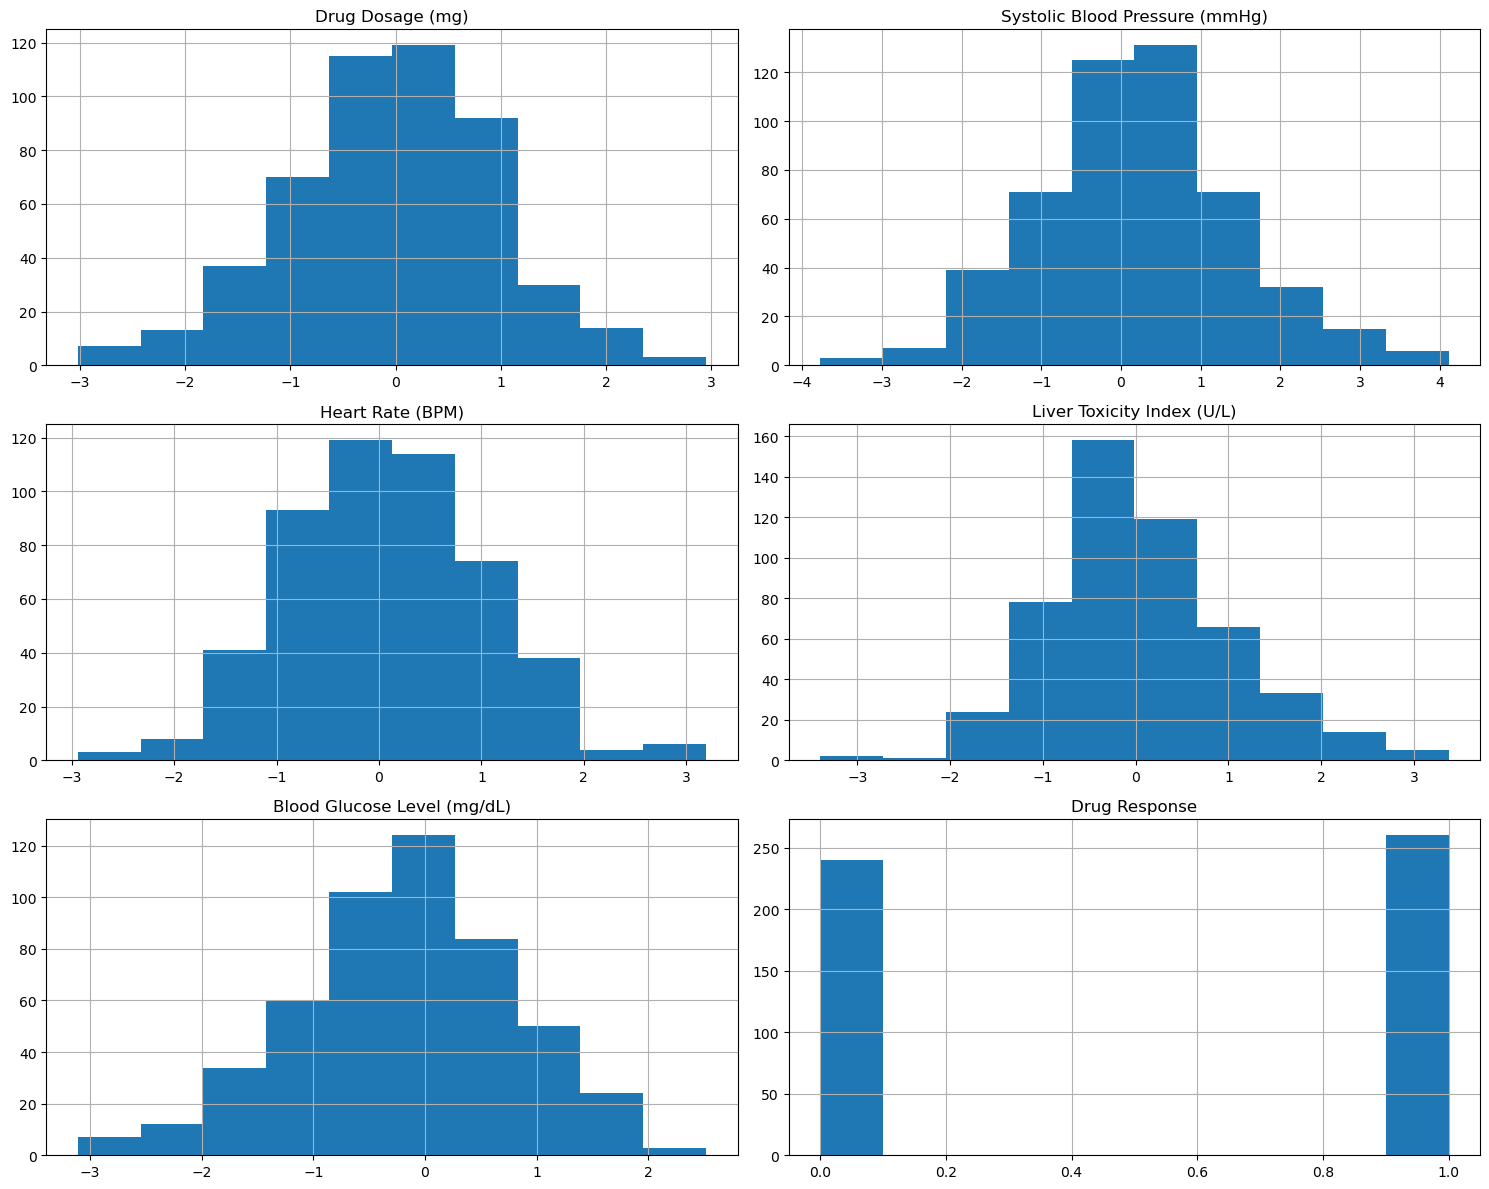

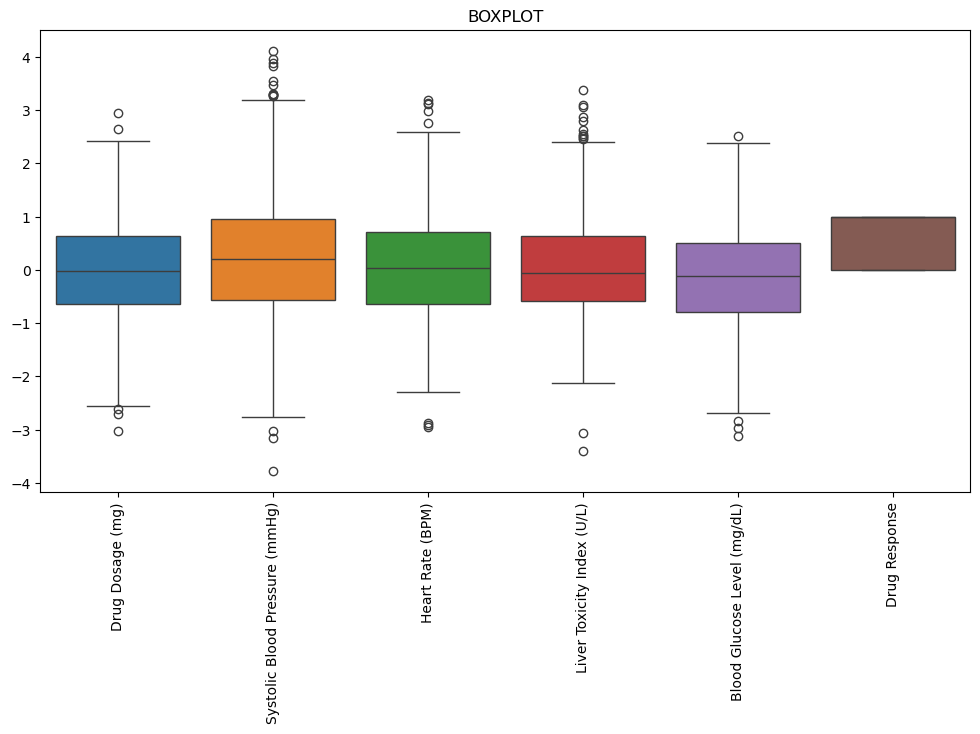

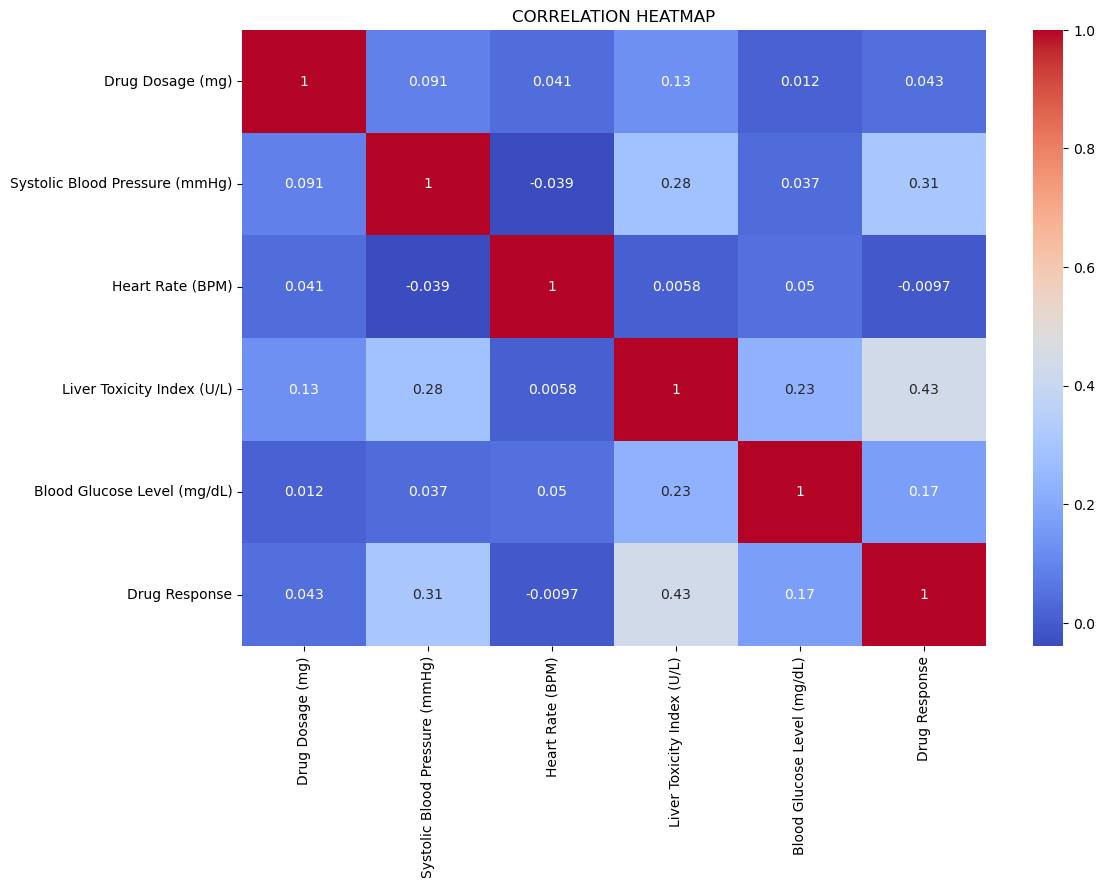


TARGET COLUMN
Drug Response


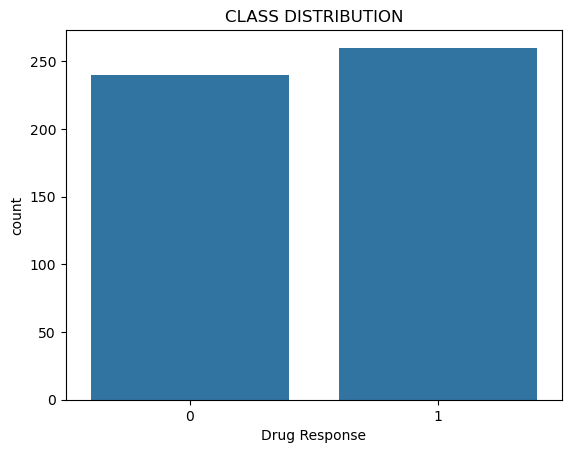


ENCODED DATA
   Drug Dosage (mg)  Systolic Blood Pressure (mmHg)  Heart Rate (BPM)  \
0         -0.128538                        0.303280         -1.881849   
1         -1.846188                        2.865142         -0.929511   
2         -1.252393                       -1.541613          0.363632   
3          1.992515                       -1.142779         -0.766657   
4          0.377100                        0.538410         -0.029263   

   Liver Toxicity Index (U/L)  Blood Glucose Level (mg/dL)  Drug Response  
0                    0.258286                    -0.792011              1  
1                    2.866786                    -0.719447              1  
2                   -0.325370                     0.191314              0  
3                    0.975286                    -0.823355              1  
4                    1.896015                    -0.960130              1  

TRAINING DATA SHAPE
(400, 5)

TESTING DATA SHAPE
(100, 5)

MODEL ACCURACY
0.78

CLASSIFICA

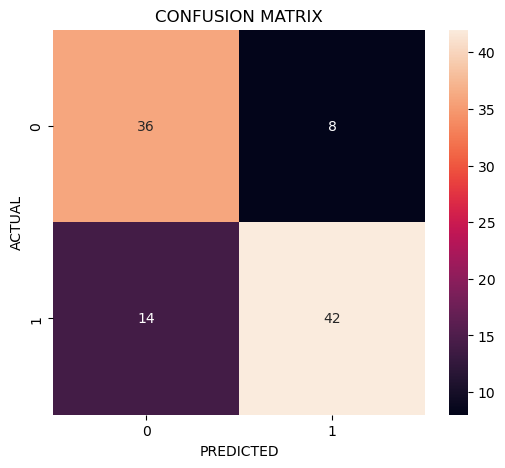


KERNEL COMPARISON

Kernel: linear
Accuracy: 0.78

Kernel: poly
Accuracy: 0.71

Kernel: rbf
Accuracy: 0.84

SVM PROJECT COMPLETED SUCCESSFULLY


In [2]:
# ==========================================================
# SUPPORT VECTOR MACHINE (SVM) PROJECT
# DRUG RESPONSE CLASSIFICATION
# COMPLETE WORKING JUPYTER NOTEBOOK CODE
# ==========================================================

# ==========================================================
# STEP 1 - IMPORT LIBRARIES
# ==========================================================

# Data handling libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# ==========================================================
# STEP 2 - LOAD DATASET
# ==========================================================

# Load dataset
# Make sure CSV file is in same folder as notebook

df = pd.read_csv("C:\\Users\\gagan\\Downloads\\Pharma_Industry (1).csv")

# Display first 5 rows

print("FIRST 5 ROWS")
print(df.head())

# ==========================================================
# STEP 3 - DATA EXPLORATION
# ==========================================================

# Shape of dataset

print("\nDATASET SHAPE")
print(df.shape)

# Column names

print("\nCOLUMN NAMES")
print(df.columns)

# Data types

print("\nDATA TYPES")
print(df.dtypes)

# Dataset information

print("\nDATASET INFO")
print(df.info())

# Summary statistics

print("\nSUMMARY STATISTICS")
print(df.describe())

# ==========================================================
# STEP 4 - CHECK MISSING VALUES
# ==========================================================

print("\nMISSING VALUES")
print(df.isnull().sum())

# ==========================================================
# STEP 5 - HANDLE MISSING VALUES
# ==========================================================

# Replace ? with NaN

df = df.replace("?", np.nan)

# Remove extra spaces from text columns

for col in df.select_dtypes(include='object').columns:
    
    df[col] = df[col].str.strip()

# Fill missing categorical values using mode

for col in df.select_dtypes(include='object').columns:
    
    df[col] = df[col].fillna(
        df[col].mode()[0]
    )

# Fill missing numerical values using median

for col in df.select_dtypes(include=['int64', 'float64']).columns:
    
    df[col] = df[col].fillna(
        df[col].median()
    )

print("\nMISSING VALUES AFTER CLEANING")
print(df.isnull().sum())

# ==========================================================
# STEP 6 - HISTOGRAMS
# ==========================================================

df.hist(figsize=(15,12))

plt.tight_layout()

plt.show()

# ==========================================================
# STEP 7 - BOXPLOT
# ==========================================================

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df.select_dtypes(include=np.number)
)

plt.xticks(rotation=90)

plt.title("BOXPLOT")

plt.show()

# ==========================================================
# STEP 8 - HEATMAP
# ==========================================================

# Create copy for heatmap

df_heatmap = df.copy()

# Encode categorical columns

le = LabelEncoder()

for col in df_heatmap.select_dtypes(include='object').columns:
    
    df_heatmap[col] = le.fit_transform(
        df_heatmap[col]
    )

# Plot heatmap

plt.figure(figsize=(12,8))

sns.heatmap(
    df_heatmap.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("CORRELATION HEATMAP")

plt.show()

# ==========================================================
# STEP 9 - TARGET COLUMN
# ==========================================================

# Automatically select last column as target

target_column = df.columns[-1]

print("\nTARGET COLUMN")
print(target_column)

# ==========================================================
# STEP 10 - CLASS DISTRIBUTION
# ==========================================================

sns.countplot(
    x=target_column,
    data=df
)

plt.title("CLASS DISTRIBUTION")

plt.show()

# ==========================================================
# STEP 11 - ENCODE CATEGORICAL VARIABLES
# ==========================================================

label_encoder = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    
    df[col] = label_encoder.fit_transform(
        df[col]
    )

print("\nENCODED DATA")
print(df.head())

# ==========================================================
# STEP 12 - FEATURES AND TARGET
# ==========================================================

# Features

X = df.drop(target_column, axis=1)

# Target

y = df[target_column]

# ==========================================================
# STEP 13 - TRAIN TEST SPLIT
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTRAINING DATA SHAPE")
print(X_train.shape)

print("\nTESTING DATA SHAPE")
print(X_test.shape)

# ==========================================================
# STEP 14 - FEATURE SCALING
# ==========================================================

scaler = StandardScaler()

# Scale training data

X_train = scaler.fit_transform(X_train)

# Scale testing data

X_test = scaler.transform(X_test)

# ==========================================================
# STEP 15 - BUILD SVM MODEL
# ==========================================================

svm_model = SVC(kernel='linear')

# ==========================================================
# STEP 16 - TRAIN MODEL
# ==========================================================

svm_model.fit(X_train, y_train)

# ==========================================================
# STEP 17 - MAKE PREDICTIONS
# ==========================================================

y_pred = svm_model.predict(X_test)

# ==========================================================
# STEP 18 - MODEL ACCURACY
# ==========================================================

accuracy = accuracy_score(y_test, y_pred)

print("\nMODEL ACCURACY")
print(accuracy)

# ==========================================================
# STEP 19 - CLASSIFICATION REPORT
# ==========================================================

print("\nCLASSIFICATION REPORT")
print(classification_report(y_test, y_pred))

# ==========================================================
# STEP 20 - CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("PREDICTED")

plt.ylabel("ACTUAL")

plt.title("CONFUSION MATRIX")

plt.show()

# ==========================================================
# STEP 21 - DIFFERENT SVM KERNELS
# ==========================================================

kernels = ['linear', 'poly', 'rbf']

print("\nKERNEL COMPARISON")

for kernel in kernels:
    
    model = SVC(kernel=kernel)
    
    # Train model
    
    model.fit(X_train, y_train)
    
    # Predictions
    
    pred = model.predict(X_test)
    
    # Accuracy
    
    acc = accuracy_score(y_test, pred)
    
    print(f"\nKernel: {kernel}")
    print(f"Accuracy: {acc}")

# ==========================================================
# STEP 22 - FINAL MESSAGE
# ==========================================================

print("\nSVM PROJECT COMPLETED SUCCESSFULLY")